# entrenamiento del modelo cnn
clasificador de celulares, laptops y relojes.

## importación de librerías

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

## carga de datos y split

In [3]:
# configuración de parámetros
batch_size = 16
img_height = 224
img_width = 224
data_dir = "dataset"

# carga del dataset desde la carpeta y split del 20%
print("cargando datos de entrenamiento...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

print("cargando datos de validación...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print(f"clases detectadas: {class_names}")

cargando datos de entrenamiento...
Found 225 files belonging to 3 classes.
Using 180 files for training.
cargando datos de validación...
Found 225 files belonging to 3 classes.
Using 45 files for validation.
clases detectadas: ['celulares', 'laptops', 'relojes']


## data augmentation

In [4]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

/Users/javier/Downloads/clasificador-objetos/venv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## arquitectura de la cnn

In [10]:
# construcción de la cnn capa por capa
num_classes = len(class_names)

modelo = models.Sequential([
    data_augmentation,
    # estandarización de los pixeles de 0-255 a 0-1
    layers.Rescaling(1./255),
    
    # extracción de características (convoluciones)
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    
    # clasificación final
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

modelo.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

modelo.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

## entrenamiento

In [5]:
epochs = 15
print("iniciando entrenamiento...")
history = modelo.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)
print("entrenamiento finalizado.")

iniciando entrenamiento...
Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 396ms/step - accuracy: 0.3167 - loss: 1.2865 - val_accuracy: 0.4444 - val_loss: 0.9832
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 423ms/step - accuracy: 0.4111 - loss: 1.0638 - val_accuracy: 0.6222 - val_loss: 0.9290
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 390ms/step - accuracy: 0.5222 - loss: 1.0302 - val_accuracy: 0.6444 - val_loss: 0.9722
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 376ms/step - accuracy: 0.5667 - loss: 0.9229 - val_accuracy: 0.6889 - val_loss: 0.9911
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 465ms/step - accuracy: 0.6611 - loss: 0.8454 - val_accuracy: 0.6667 - val_loss: 0.7451
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 410ms/step - accuracy: 0.5111 - loss: 0.9534 - val_accuracy: 0.6667 - val_loss: 0.7393
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 412ms/step - accuracy: 0.6833 - loss: 0.8000 - val_accuracy: 0.7556 - val_loss: 0.6462
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 413ms/step - accuracy: 0.7056 - loss

## evaluación y resultados

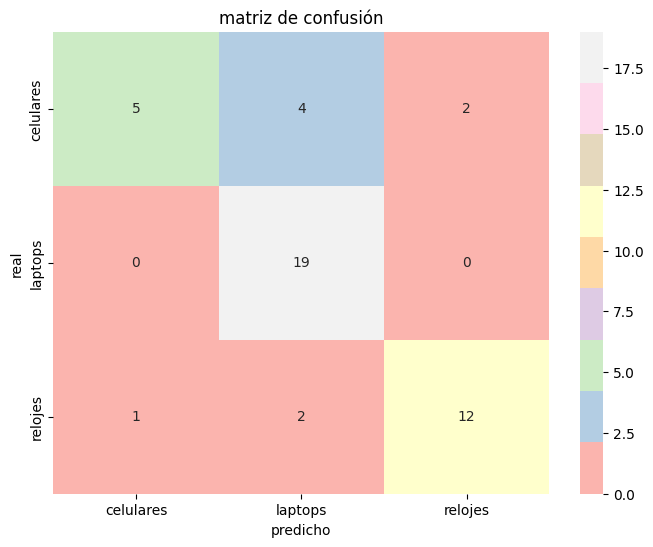

              precision    recall  f1-score   support

   celulares       0.83      0.45      0.59        11
     laptops       0.76      1.00      0.86        19
     relojes       0.86      0.80      0.83        15

    accuracy                           0.80        45
   macro avg       0.82      0.75      0.76        45
weighted avg       0.81      0.80      0.78        45



In [10]:
# generación de predicciones sobre el set de validación
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = modelo.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# matriz de confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Pastel1', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('predicho')
plt.ylabel('real')
plt.title('matriz de confusión')
plt.show()

# reporte detallado
print(classification_report(y_true, y_pred, target_names=class_names))

---

# fine-tuning

## importación de nuevas herramientas

In [8]:
from tensorflow.keras import regularizers, callbacks

## data augmentation 2

In [12]:
# agregamos traslación y contraste para mayor generalización
data_augmentation_robusto = tf.keras.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2), 
    layers.RandomZoom(0.2),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomContrast(0.1)
])

## arquitectura 2

In [13]:
# creamos una instancia completamente nueva para no pisar el modelo anterior
modelo_robusto = models.Sequential([
    data_augmentation_robusto,
    layers.Rescaling(1./255),
    
    # bloque 1
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    
    # bloque 2
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    
    # bloque 3
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),
    
    # bloque 4
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.4),
    
    # clasificación final
    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

modelo_robusto.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

## entrenamiento 2

In [14]:
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

epochs_robust = 30
print("iniciando entrenamiento del modelo robusto...")

history_robusto = modelo_robusto.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_robust,
    callbacks=[early_stop, reduce_lr]
)
print("entrenamiento finalizado.")

iniciando entrenamiento del modelo robusto...
Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 795ms/step - accuracy: 0.4889 - loss: 1.8775 - val_accuracy: 0.2444 - val_loss: 2.4236 - learning_rate: 0.0010
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 621ms/step - accuracy: 0.5444 - loss: 1.7112 - val_accuracy: 0.2444 - val_loss: 4.2045 - learning_rate: 0.0010
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 580ms/step - accuracy: 0.5278 - loss: 1.6384 - val_accuracy: 0.3778 - val_loss: 3.4587 - learning_rate: 0.0010
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 621ms/step - accuracy: 0.6167 - loss: 1.4334 - val_accuracy: 0.4222 - val_loss: 3.0861 - learning_rate: 0.0010
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 596ms/step - accuracy: 0.5778 - loss: 1.5526 - val_accuracy: 0.4444 - val_loss: 4.9708 - learning_rate: 5.0000e-04
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 614ms/step - accuracy: 0.6444 - loss: 1.3493 - val_accuracy: 0.4222 - val_loss: 3.5069 - learning_rate: 5.0000e-04
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━

## evaluación 2

In [ ]:
# evaluamos específicamente este nuevo modelo
y_true_robusto = []
y_pred_robusto = []

for images, labels in val_ds:
    predictions = modelo_robusto.predict(images, verbose=0)
    y_true_robusto.extend(labels.numpy())
    y_pred_robusto.extend(np.argmax(predictions, axis=1))

print("\n--- reporte del modelo robusto ---")
print(classification_report(y_true_robusto, y_pred_robusto, target_names=class_names))

# guardamos esta segunda versión
#modelo_robusto.save('modelo_robusto.h5')
print("modelo guardado como 'modelo_robusto.h5'")

/Users/javier/Downloads/clasificador-objetos/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/javier/Downloads/clasificador-objetos/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/javier/Downloads/clasificador-objetos/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio


--- reporte del modelo robusto ---
              precision    recall  f1-score   support

   celulares       0.24      1.00      0.39        11
     laptops       0.00      0.00      0.00        19
     relojes       0.00      0.00      0.00        15

    accuracy                           0.24        45
   macro avg       0.08      0.33      0.13        45
weighted avg       0.06      0.24      0.10        45

modelo guardado como 'modelo_robusto.h5'


---
## arquitectura 3

In [16]:
modelo_robusto = models.Sequential([
    data_augmentation_robusto,
    layers.Rescaling(1./255),
    
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.2), # reducimos el apagón de neuronas
    
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.2), # reducimos el apagón de neuronas
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'), # eliminamos la regularización l2 que asfixiaba la capa
    layers.BatchNormalization(),
    layers.Dropout(0.3), # bajamos del 50% al 30%
    layers.Dense(num_classes, activation='softmax')
])

modelo_robusto.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

## entrenamiento 3

In [17]:
# 12 épocas de tolerancia antes de que aborte el entrenamiento
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)

epochs_robust = 40
print("iniciando entrenamiento del modelo corregido...")

history_robusto = modelo_robusto.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_robust,
    callbacks=[early_stop, reduce_lr]
)
print("entrenamiento finalizado.")

iniciando entrenamiento del modelo corregido...
Epoch 1/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 689ms/step - accuracy: 0.5278 - loss: 1.4551 - val_accuracy: 0.3333 - val_loss: 2.4100 - learning_rate: 0.0010
Epoch 2/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 583ms/step - accuracy: 0.6167 - loss: 0.9916 - val_accuracy: 0.3333 - val_loss: 7.3106 - learning_rate: 0.0010
Epoch 3/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 623ms/step - accuracy: 0.6389 - loss: 0.9548 - val_accuracy: 0.3333 - val_loss: 6.8020 - learning_rate: 0.0010
Epoch 4/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 595ms/step - accuracy: 0.5722 - loss: 1.0196 - val_accuracy: 0.3333 - val_loss: 5.8990 - learning_rate: 0.0010
Epoch 5/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 663ms/step - accuracy: 0.6500 - loss: 0.8236 - val_accuracy: 0.3333 - val_loss: 4.2553 - learning_rate: 0.0010
Epoch 6/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 631ms/step - accuracy: 0.6111 - loss: 0.9749 - val_accuracy: 0.3333 - val_loss: 4.8369 - learning_rate: 5.0000e-04
Epoch 7/40
12/12 ━━━━━━━━━━━━━━━━━━

---
## arquitectura 4

In [11]:
# regresamos a un augmentation más amigable
data_augmentation_final = tf.keras.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15)
])

modelo_final = models.Sequential([
    data_augmentation_final,
    layers.Rescaling(1./255),
    
    # extracción limpia (1er modelo)
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    
    # clasificación protegida
    layers.Flatten(),
    layers.Dropout(0.4), # pa que no memorice la época 7
    layers.Dense(64, activation='relu'), # reducimos de 128 a 64 neuronas
    layers.Dense(num_classes, activation='softmax')
])

modelo_final.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

## entrenamiento 4

In [19]:
early_stop_final = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr_final = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

print("iniciando entrenamiento del modelo final...")
history_final = modelo_final.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,
    callbacks=[early_stop_final, reduce_lr_final]
)

iniciando entrenamiento del modelo final...
Epoch 1/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 367ms/step - accuracy: 0.3500 - loss: 1.3727 - val_accuracy: 0.4889 - val_loss: 1.0274 - learning_rate: 0.0010
Epoch 2/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 356ms/step - accuracy: 0.4056 - loss: 1.0675 - val_accuracy: 0.5556 - val_loss: 0.9062 - learning_rate: 0.0010
Epoch 3/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 353ms/step - accuracy: 0.5222 - loss: 0.9554 - val_accuracy: 0.6222 - val_loss: 0.7208 - learning_rate: 0.0010
Epoch 4/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 381ms/step - accuracy: 0.5444 - loss: 0.9250 - val_accuracy: 0.6444 - val_loss: 0.9085 - learning_rate: 0.0010
Epoch 5/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 342ms/step - accuracy: 0.5611 - loss: 0.8728 - val_accuracy: 0.6889 - val_loss: 0.6749 - learning_rate: 0.0010
Epoch 6/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 347ms/step - accuracy: 0.6556 - loss: 0.8130 - val_accuracy: 0.7333 - val_loss: 0.8347 - learning_rate: 0.0010
Epoch 7/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 377

## evaluación final


--- reporte del modelo final ---
              precision    recall  f1-score   support

   celulares       0.88      0.64      0.74        11
     laptops       0.86      1.00      0.93        19
     relojes       0.87      0.87      0.87        15

    accuracy                           0.87        45
   macro avg       0.87      0.83      0.84        45
weighted avg       0.87      0.87      0.86        45



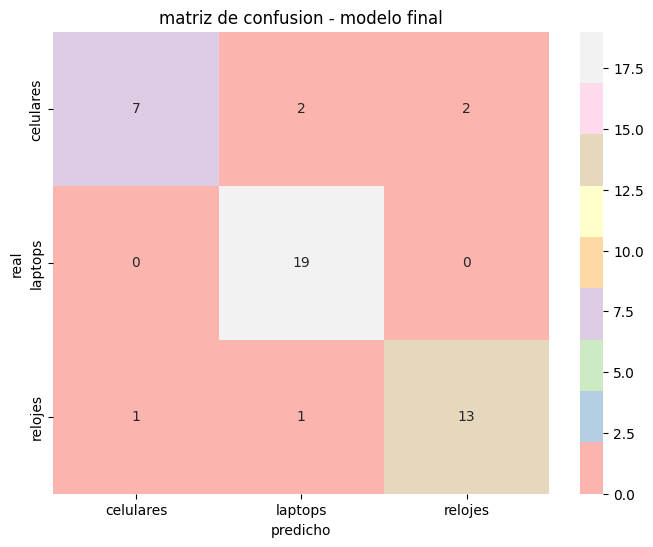

In [21]:
y_true_final = []
y_pred_final = []

for images, labels in val_ds:
    predictions = modelo_final.predict(images, verbose=0)
    y_true_final.extend(labels.numpy())
    y_pred_final.extend(np.argmax(predictions, axis=1))

print("\n--- reporte del modelo final ---")
print(classification_report(y_true_final, y_pred_final, target_names=class_names))

# matriz de confusión para ver si ya no confunde celulares con laptops
cm_final = confusion_matrix(y_true_final, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Pastel1', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('predicho')
plt.ylabel('real')
plt.title('matriz de confusion - modelo final')
plt.show()

modelo_final.save('modelo_definitivo.keras')

## visualización de predicciones

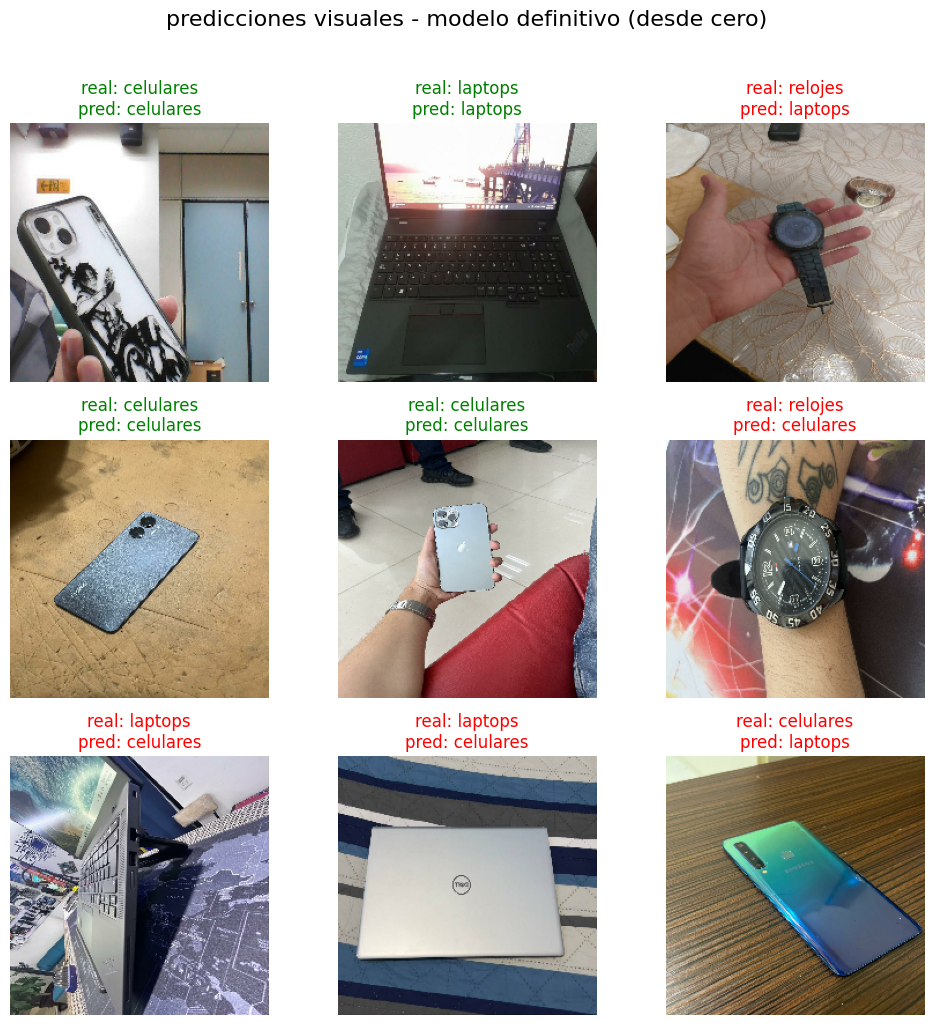

In [17]:
plt.figure(figsize=(10, 10))

for images, labels in val_ds.take(1):
    preds = modelo_final.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)

    # max. 9 imagenes 3x3
    for i in range(min(9, len(images))): 
        ax = plt.subplot(3, 3, i + 1)
        
        # keras usa tensors en float, convertimos a uint8 para matplotlib
        plt.imshow(images[i].numpy().astype("uint8"))
        
        real_label = class_names[labels[i]]
        pred_label = class_names[pred_classes[i]]

        color = 'green' if real_label == pred_label else 'red'
        
        plt.title(f"real: {real_label}\npred: {pred_label}", color=color)
        plt.axis("off")

plt.suptitle("predicciones visuales - modelo definitivo (desde cero)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
# transfer learning
mobilenetv2

## importación y configuración

In [5]:
# descargamos mobilenetv2 sin su capa final de clasificación (include_top=false)
print("descargando mobilenetv2...")
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)

# congelamos los pesos de google para no destruirlos durante nuestro entrenamiento
base_model.trainable = False

descargando mobilenetv2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


## arquitectura

In [ ]:
modelo_tl = models.Sequential([
    # reusamos el último data augmentation
    data_augmentation_final,
    
    # nota: mobilenetv2 espera que los pixeles esten entre -1 y 1 (no 0 y 1)
    layers.Rescaling(1./127.5, offset=-1),
    
    # metemos el cerebro entero de google como si fuera una sola capa
    base_model,
    
    # convertimos los mapas de caracteristícas a un formato plano
    layers.GlobalAveragePooling2D(),
    
    # un poco de dropout para no sobreajustar nuestra pequeña capa final
    layers.Dropout(0.2),
    
    # nuestra capa final de decisión para celulares, laptops y relojes
    layers.Dense(num_classes, activation='softmax')
])

modelo_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # tasa de aprendizaje un poco mas alta inicial
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

modelo_tl.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## entrenamiento

In [13]:
# con transfer learning, la red aprende muchísimo más rápido. 
# le daremos 15 épocas, pero el early stop lo detendrá antes si ya es perfecto.
early_stop_tl = callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

print("iniciando entrenamiento con transfer learning...")
history_tl = modelo_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop_tl]
)

iniciando entrenamiento con transfer learning...
Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 298ms/step - accuracy: 0.4722 - loss: 1.0664 - val_accuracy: 0.8444 - val_loss: 0.5345
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 292ms/step - accuracy: 0.7278 - loss: 0.6444 - val_accuracy: 0.8889 - val_loss: 0.3466
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 211ms/step - accuracy: 0.8333 - loss: 0.3944 - val_accuracy: 0.9111 - val_loss: 0.2459
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step - accuracy: 0.9278 - loss: 0.2605 - val_accuracy: 0.9556 - val_loss: 0.2050
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 195ms/step - accuracy: 0.9222 - loss: 0.2330 - val_accuracy: 0.9556 - val_loss: 0.1848
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 204ms/step - accuracy: 0.9556 - loss: 0.1800 - val_accuracy: 0.9556 - val_loss: 0.1686
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 276ms/step - accuracy: 0.9556 - loss: 0.1690 - val_accuracy: 0.9556 - val_loss: 0.1612
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 396ms/step - a

## evaluación

              precision    recall  f1-score   support

   celulares       1.00      0.91      0.95        11
     laptops       1.00      1.00      1.00        19
     relojes       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



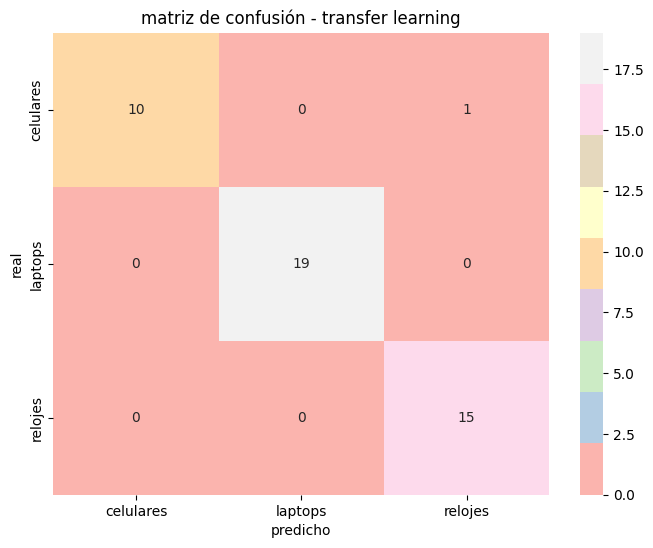

modelo de transfer learning guardado como 'modelo_transfer_learning.keras'


In [15]:
y_true_tl = []
y_pred_tl = []

for images, labels in val_ds:
    predictions = modelo_tl.predict(images, verbose=0)
    y_true_tl.extend(labels.numpy())
    y_pred_tl.extend(np.argmax(predictions, axis=1))

print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Pastel1', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('predicho')
plt.ylabel('real')
plt.title('matriz de confusión - transfer learning')
plt.show()

modelo_tl.save('modelo_transfer_learning.keras')
print("modelo de transfer learning guardado como 'modelo_transfer_learning.keras'")

## visualización de predicciones

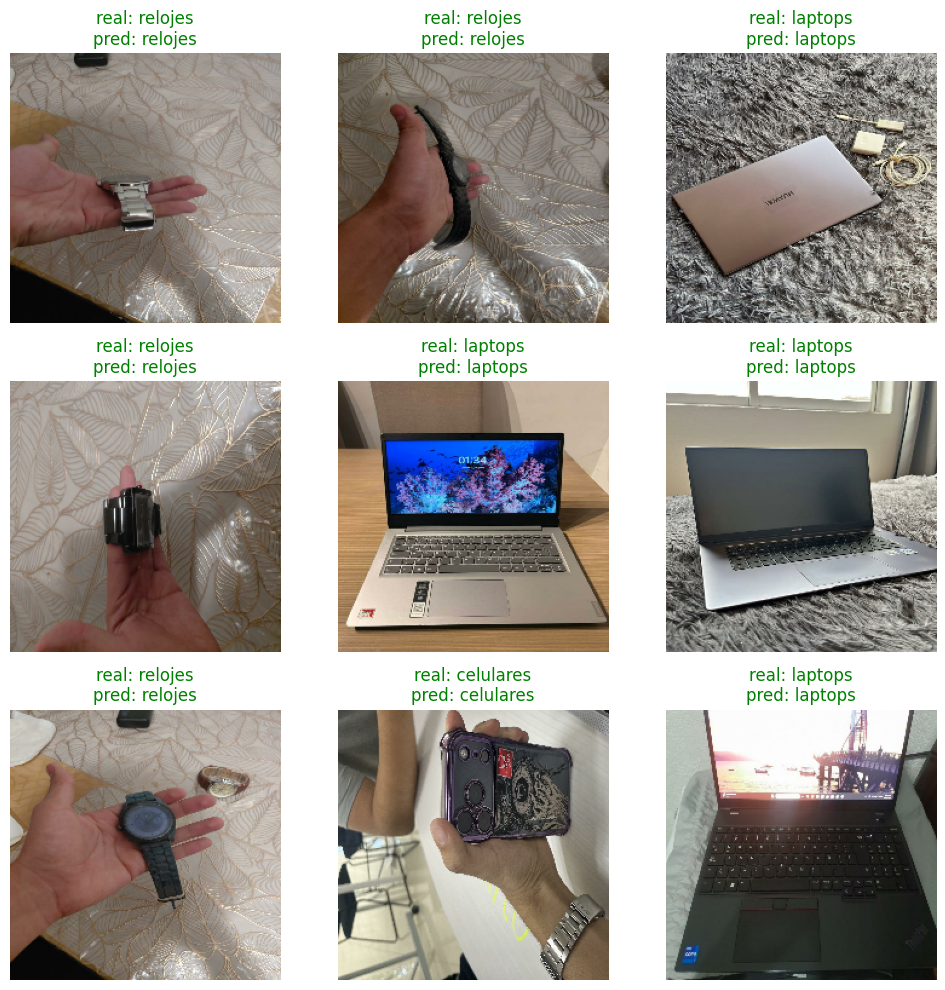

In [16]:
# 1 batch, 16 imágenes del val set
plt.figure(figsize=(10, 10))

for images, labels in val_ds.take(1):
    preds = modelo_tl.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)

    # máx. 9 imágenes 3x3
    for i in range(min(9, len(images))): 
        ax = plt.subplot(3, 3, i + 1)
        
        # keras usa tensors en float, convertimos a uint8 para matplotlib
        plt.imshow(images[i].numpy().astype("uint8"))
        
        real_label = class_names[labels[i]]
        pred_label = class_names[pred_classes[i]]

        color = 'green' if real_label == pred_label else 'red'
        
        plt.title(f"real: {real_label}\npred: {pred_label}", color=color)
        plt.axis("off")

plt.tight_layout()
plt.show()